In [10]:
para = """ 

I am working as a AI engineer at the best brains organization.
I want to learn concepts from the AI and get better at the fundamentals.
I want to be aware of all the major concepts in the field.
So, now I am sitting and learning the embeddings and how does they work.
Embedding model actually takes the raw text and convert them into the vector representation of the text.
Vector is a mathemetical representation, basically a list of integers that carry some meaning.
So a vector representation of a word, some how carries the meaning of the word.
So when embedding models convert the words into the vector representations, they carry the sematic meaning of the words with them.
Now we need a place to store these embeddings, and the embeddings can't be stored in a normal databases.
So we get introduced to a new concept call a vector database. As the name conveys , a vector database is a storage for storing embeddings.
But I guess we can store the embeddings in normal databases as well.
But there are some tradeoffs when we are comparing storing the embeddings in regular DB vs in vector DBs.
Since Vector Databases are purposefully built for storing vector embeddings, they natually have edge when it comes to the task.
As in Normal Databases can be slow when compared to vector DBs while performing the cosine similarity.
But honeslty, daily exercising can improve our mental health, while simultaneously keeping us in shape.
But we should be careful while exercising not to cross our limit and do ego lifiting , which can lead to permanent injuries.
Normal Databases can be quickly run out of memory when storing high dimensional embeddings and also gets slow, theoretically better under 10 million vectors , where as the Vector Database were built to handle Billions of the vector embeddings.
But one advantage of using normal databases is that we don't need to setup a new tool for storing vector embeddings.
But that itself can be an issue, when all the operational business data is mingled with the high dimesional vectors in huge numbers.
But Vector databases can be a dis advantages for someone who is very new to the AI world, so that he has to learn a separate tool to setup the database, when compared to traditional databases.

"""

In [11]:
sentences = [
    # --- Paraphrases (expect HIGH ~0.8+) ---
    "Vector databases are purpose-built for storing embeddings.",              # 0
    "Vector DBs are specifically designed to hold vector embeddings.",         # 1
    "A vector database can efficiently store high-dimensional vectors.",       # 2
    "High-dimensional embeddings are stored efficiently in a vector database.",# 3
    "Cosine similarity search is very fast in a vector database.",             # 4
    "Vector databases perform similarity search quickly.",                     # 5
    "Relational databases store structured business data in tables.",          # 6
    "Traditional databases keep operational data in rows and columns.",        # 7

    # --- Opposites: lexically close, semantically opposite (THE trap) ---
    "Vector databases are faster than relational databases at similarity search.",  # 8
    "Vector databases are slower than relational databases at similarity search.",  # 9
    "Relational databases scale well to billions of vectors.",                 # 10
    "Relational databases scale poorly to billions of vectors.",               # 11
    "The vector index fits entirely in memory.",                               # 12
    "The vector index does not fit in memory.",                                # 13
    "Storing embeddings in a normal database is a good idea.",                 # 14
    "Storing embeddings in a normal database is a bad idea.",                  # 15

    # --- Same word, different meaning (polysemy trap) ---
    "An embedding is stored as a vector inside the database.",                 # 16
    "Mosquitoes act as a vector for spreading disease.",                       # 17  ("vector")
    "The vector database builds an HNSW index for fast lookup.",               # 18
    "She flipped to the index at the back of the book.",                       # 19  ("index")
    "Vector databases scale to billions of records.",                          # 20
    "He stepped on the bathroom scale this morning.",                          # 21  ("scale")

    # --- Same topic, genuinely different claim (expect MEDIUM) ---
    "Vector databases run approximate nearest-neighbor search.",               # 22
    "Relational databases guarantee ACID transactions.",                       # 23
    "Vector databases handle unstructured, high-dimensional data.",            # 24
    "Relational databases enforce strict, predefined schemas.",                # 25
    "Setting up a vector database means learning a new tool.",                 # 26
    "Relational databases are already familiar to most developers.",           # 27

    # --- Subtle: near-identical wording, contradictory number (nasty trap) ---
    "Normal databases slow down past roughly 10 million vectors.",             # 28
    "Normal databases stay fast well beyond 10 million vectors.",              # 29
    "Vector databases were designed to handle billions of embeddings.",        # 30
    "A dedicated vector store adds operational overhead to maintain.",         # 31
    "Reusing your existing database avoids adding new infrastructure.",        # 32

    # --- Unrelated to the DB topic (expect LOW vs everything above) ---
    "Daily exercise improves both mood and physical health.",                  # 33
    "Ego lifting at the gym can cause permanent injury.",                      # 34
    "I had pasta with garlic bread for dinner.",                               # 35
    "The sunset painted the sky orange over the hills.",                       # 36
    "My cat knocked a glass off the kitchen counter.",                         # 37
    "We booked flight tickets for the weekend trip.",                          # 38
    "The river flooded the village after three days of rain.",                 # 39
]

# CONVENTION: the value is the TRUE (human-judged) relationship.
# A trailing "?" = "this is a trap — I bet the model's score WON'T match the truth."
expected = {
    # paraphrases — no trap, model should agree
    (0, 1):  "high",
    (2, 3):  "high",
    (4, 5):  "high",

    # opposites — truth is LOW (opposite meaning), but I bet the model scores HIGH
    (8, 9):  "low?",   # faster / slower — nearly identical words
    (10, 11):"low?",   # scale well / poorly
    (12, 13):"low?",   # fits / does not fit in memory
    (14, 15):"low?",   # good idea / bad idea
    (28, 29):"low?",   # slows down / stays fast past 10M — the nastiest one

    # polysemy — truth is LOW (different meanings), trap = shared surface word pulls it up
    (16, 17):"low?",   # "vector": embedding vs disease vector
    (18, 19):"low?",   # "index": HNSW index vs book index
    (20, 21):"low?",   # "scale": scale to billions vs bathroom scale

    # same topic, different claim — expect MEDIUM, probably no dramatic trap
    (22, 23):"med",
    (24, 25):"med",

    # hidden cluster INSIDE the "unrelated" block — these two relate to EACH OTHER
    (33, 34):"high",   # both gym/health — will cluster warm even though off-DB-topic

    # genuinely unrelated — no trap, should be low
    (0, 35): "low",    # vector DB vs pasta
    (4, 36): "low",    # similarity search vs sunset
    (0, 33): "low",    # DB vs exercise
}

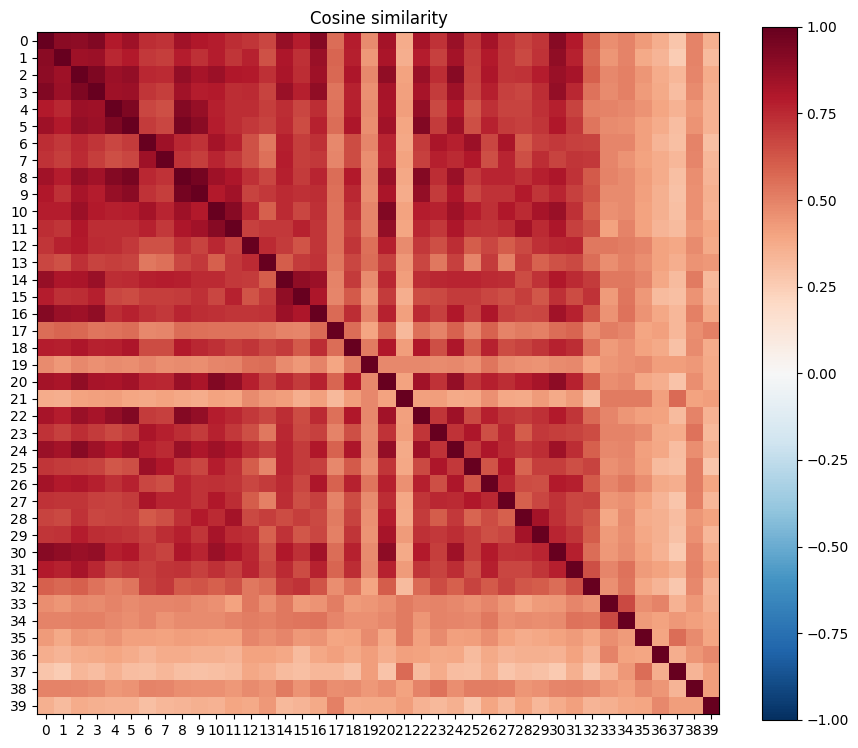

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-small-en-v1.5")   # you already know BGE
emb = model.encode(sentences, convert_to_numpy=True)     # raw, unnormalized

def l2(x): return x / np.linalg.norm(x, axis=1, keepdims=True)
cos = l2(emb) @ l2(emb).T

plt.figure(figsize=(11, 9))
plt.imshow(cos, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(); plt.title("Cosine similarity")
plt.xticks(range(len(sentences)), range(len(sentences)))
plt.yticks(range(len(sentences)), range(len(sentences)))
plt.show()

In [13]:
import numpy as np

# cosine of ONE pair, written the long way so every step is visible
def cosine(a, b):
    dot   = np.dot(a, b)              # A·B
    len_a = np.linalg.norm(a)        # ‖A‖
    len_b = np.linalg.norm(b)        # ‖B‖
    return dot / (len_a * len_b)

# --- A) your labelled pairs, with sentences printed so you can read them ---
print("="*80)
print("YOUR LABELLED PAIRS  (you predicted a label; now see the real score)")
print("="*80)
for (i, j), truth in expected.items():
    score = cosine(emb[i], emb[j])
    print(f"cos={score:+.3f}  you_said={truth:6s}")
    print(f"    [{i}] {sentences[i]}")
    print(f"    [{j}] {sentences[j]}\n")

# --- B) every pair, ranked most-similar to least-similar ---
pairs = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):        # j>i so we skip the diagonal & duplicates
        pairs.append((cosine(emb[i], emb[j]), i, j))
pairs.sort(reverse=True)

print("="*80)
print("TOP 8 MOST SIMILAR PAIRS  (watch your OPPOSITES show up here — the trap)")
print("="*80)
for s, i, j in pairs[:8]:
    print(f"{s:+.3f}  [{i}] {sentences[i][:38]:38s} | [{j}] {sentences[j][:38]}")

print("\n" + "="*80)
print("BOTTOM 8 LEAST SIMILAR PAIRS  (your unrelated sentences should land here)")
print("="*80)
for s, i, j in pairs[-8:]:
    print(f"{s:+.3f}  [{i}] {sentences[i][:38]:38s} | [{j}] {sentences[j][:38]}")

# --- C) prove the matrix and the manual formula agree ---
print("\nmanual cosine(0,1):", round(cosine(emb[0], emb[1]), 4))
print("matrix   cos[0,1] :", round(float(cos[0, 1]), 4), " <- should match exactly")

YOUR LABELLED PAIRS  (you predicted a label; now see the real score)
cos=+0.904  you_said=high  
    [0] Vector databases are purpose-built for storing embeddings.
    [1] Vector DBs are specifically designed to hold vector embeddings.

cos=+0.936  you_said=high  
    [2] A vector database can efficiently store high-dimensional vectors.
    [3] High-dimensional embeddings are stored efficiently in a vector database.

cos=+0.936  you_said=high  
    [4] Cosine similarity search is very fast in a vector database.
    [5] Vector databases perform similarity search quickly.

cos=+0.957  you_said=low?  
    [8] Vector databases are faster than relational databases at similarity search.
    [9] Vector databases are slower than relational databases at similarity search.

cos=+0.912  you_said=low?  
    [10] Relational databases scale well to billions of vectors.
    [11] Relational databases scale poorly to billions of vectors.

cos=+0.743  you_said=low?  
    [12] The vector index fits entir

Cosine Similarity : Cosine similarity between two vectors captures the conceptual relatedness between one another,where as it doesn't gaurantee the factual accuracy between the two vectors.

In [14]:
print("raw norms:", np.linalg.norm(emb, axis=1)[:5])   # are they already ~1.0?

dot_raw  = emb @ emb.T          # magnitude matters
dot_norm = l2(emb) @ l2(emb).T  # this IS cosine
print("cosine == normalized-dot? max diff:", np.abs(dot_norm - cos).max())  # ~0

raw norms: [1. 1. 1. 1. 1.]
cosine == normalized-dot? max diff: 0.0


Normalization : Basically each vector has 2 things, direction and magnitude. Mangitude is the length of the arrow from origin. Although the length of vectors doesn't change or impact the angle between 2 vectors theoretically. But in order to calculate the cosine similarity between 2 vectors. we need to normalize the vectors to length of 1 such that when normallized , their dot product directly gives the cosine similarity.

As the only information we know regarding the 2 vectors is their co ordinates, the only way to calculate the cosine angle is dot product of 2 vectors, but if we do the dot product with the original mangitude , there is chance that unrelated words results in similar scores. so we need to normalize the vectors down to 1 first, then when all vectors of same length, then we will accurately get the cosine angle between them.

Basically in high dimesional vectors the magnitude and direction are embeddeded into the coordinates of vectors. so we have to normalize the length of the vectors to a common length for accurately getting the angle.

In [15]:
mrl = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)
# nomic needs a task prefix:
docs = ["search_document: " + s for s in sentences]
full = mrl.encode(docs, convert_to_numpy=True)   # 768-d

trunc = full[:, :256]             
emb_trunc = emb[:, :96]                # slice, THEN re-normalize (important)
cos_full = l2(full)  @ l2(full).T
cos_256  = l2(trunc) @ l2(trunc).T
cos_nomral_full = l2(emb) @ l2(emb).T
cos_normal_trunc = l2(emb_trunc) @ l2(emb_trunc).T

iu = np.triu_indices_from(cos_full, k=1)
print("max change:", np.abs(cos_full - cos_256).max())
print("mean change:", np.abs(cos_full - cos_256).mean())
print("structure corr:", np.corrcoef(cos_full[iu], cos_256[iu])[0, 1])

iu = np.triu_indices_from(cos_nomral_full, k=1)
print("max change:", np.abs(cos_nomral_full - cos_normal_trunc).max())
print("mean change:", np.abs(cos_nomral_full - cos_normal_trunc).mean())
print("structure corr:", np.corrcoef(cos_nomral_full[iu], cos_normal_trunc[iu])[0, 1])

<All keys matched successfully>


max change: 0.08355868
mean change: 0.02234532
structure corr: 0.9886055080867355
max change: 0.437245
mean change: 0.13716397
structure corr: 0.9357273758507284


In [16]:
def topk(cos, k=3):
    out = []
    for i in range(len(cos)):
        order = np.argsort(-cos[i])
        out.append(set(order[order != i][:k].tolist()))   # top-k, self removed
    return out

def kept(full_cos, trunc_cos, k=3):
    A, B = topk(full_cos, k), topk(trunc_cos, k)
    return np.mean([len(A[i] & B[i]) / k for i in range(len(A))])

print("MRL    top-3 neighbours kept:", round(kept(cos_full, cos_256), 3))
print("Normal top-3 neighbours kept:", round(kept(cos_nomral_full, cos_normal_trunc), 3))

MRL    top-3 neighbours kept: 0.833
Normal top-3 neighbours kept: 0.725


Matryoshka Embeddings: The concept is to embed the most of the meaning in the early coordinates or dimensions, such that truncating the vector doens't result in a huge loss of infomration, keeping the recall high while significantly redcuing the search cost or storage cost, whatever the developer chooses. Basically in normal embeddings, the meaning of the sentence is smeared evenly across all the dimensions. so truncating in a normal embedding means loss of valuable info. where as MRL ( Matryoshka Representation Learning) is applied during the training time itself to make embeddings store info in this way.